# Project01: SVM classification using 90 regional grey-matter volumes

Following the instructor's Lab 2 **Import/Load → Split → Train/Predict/Accuracy** structure, replace the PIMA data with this project's regional brain volumes.

Project01 specifies Data_00–39 for training and Data_40–49 for testing. Each subject contributes grey-matter volumes from AAL regions 1–90 for AD/NC prediction. The original PDF's example table starts with Data_30, but the text and explicit split require Data_40–49; the output covers those 10 test subjects.

The fixed baseline is `StandardScaler + svm.SVC(kernel="rbf", C=1.0, gamma="scale")`. These kernel/parameter values are implementation choices, not instructor-mandated settings or values selected by test accuracy. Training-only five-fold CV is an additional evaluation in this implementation, not an extra Lab 2 requirement.

**Run:** open this folder in VSCode, install `requirements.txt`, select the corresponding Python kernel, and execute all cells in order. Keep the script, two volume tables, and labels together when moving to another computer.

[Running guide](RUNNING_GUIDE.md) · [Run results](RUN_RESULTS.md) · [Report evidence](report_evidence/README.md)


## Step 1: import libraries and specify files

Use `from sklearn import svm`, as in Lab 2. `StandardScaler` transforms each ROI to zero mean and unit standard deviation based on training samples. `Pipeline` combines scaling and SVM into one model.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Image
from sklearn import svm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Also locate the project when VSCode starts from its parent folder.
candidates = [Path.cwd(), Path.cwd() / "SVM", Path.cwd() / "outputs/Project01_SVM"]
PROJECT_DIR = next((p for p in candidates if (p / "project01_svm.py").is_file()), None)
if PROJECT_DIR is None:
    raise RuntimeError("Open the folder containing project01_svm.py in VSCode before running this notebook.")
sys.path.insert(0, str(PROJECT_DIR))
from project01_svm import (
    FEATURE_COLUMNS, TRAIN_IDS, TEST_IDS,
    load_feature_table, load_labels_for,
    save_predictions, save_training_record, evaluate_predictions,
)

TRAIN_CSV = PROJECT_DIR / "data/AAL_statistics_volumn_train.csv"
TEST_CSV = PROJECT_DIR / "data/AAL_statistics_volumn_test.csv"
LABELS_CSV = PROJECT_DIR / "data/data_labels.csv"
OUTPUT_DIR = PROJECT_DIR / "results"
# Compare supplied test labels only in the final step; this flag does not affect fitting or prediction.
EVALUATE_TEST = True
print("Project folder:", PROJECT_DIR)


Project folder: <repository directory>


## Step 2: load data using the prescribed training/test split

Lab 2 uses `train_test_split(test_size=0.33, random_state=73)`. This project already specifies a 40/10 split, so read its two tables directly.

- `x_train`: 40 × 90; `x_test`: 10 × 90; original units are mm³.
- `y_train`: labels joined to IDs using `New Name`; **NC=0, AD=1**.
- Strip whitespace and `.nii` suffixes to align labels; do not rely on CSV row order.
- Exclude FileName, Original Name, labels, and other metadata from the feature matrix. Select ROI columns in **numerical order 1–90**.


In [2]:
train_table = load_feature_table(TRAIN_CSV, TRAIN_IDS)
test_table = load_feature_table(TEST_CSV, TEST_IDS)
x_train = train_table.to_numpy(dtype=float)
x_test = test_table.to_numpy(dtype=float)
y_train = load_labels_for(LABELS_CSV, train_table.index.tolist())

assert x_train.shape == (40, 90) and x_test.shape == (10, 90)
assert set(np.unique(y_train)) == {0, 1}
print("x_train:", x_train.shape, "x_test:", x_test.shape)
print("Training NC:", int((y_train == 0).sum()), "AD:", int((y_train == 1).sum()))
display(train_table.iloc[:5, :6])


x_train: (40, 90) x_test: (10, 90)
Training NC: 21 AD: 19


,ROI_1_mm3,ROI_2_mm3,ROI_3_mm3,ROI_4_mm3,ROI_5_mm3,ROI_6_mm3
FileName,,,,,,
Data_00,6523.223317,4795.514146,6533.901372,6715.428293,1947.677088,2613.987671
Data_01,7723.000000,7983.000000,9151.000000,9135.000000,2659.000000,2346.000000
Data_02,8852.000000,8397.000000,5811.000000,9491.000000,2347.000000,2859.000000
Data_03,8734.238171,8293.158078,8397.568342,9762.359644,2293.829566,2563.378512
Data_04,7010.000000,6905.000000,8570.000000,8260.000000,2756.000000,2823.000000


## Step 3: cross-validate within training data, then fit all 40 subjects

This implements the Project01 equivalent of the SVM TODO in Lab 2.

`cross_val_score` receives the complete pipeline, so each fold fits its scaler only on that fold's training subset. Afterwards, `model.fit(x_train, y_train)` refits the scaler and SVM on all 40 training subjects.

Five-fold CV uses Lab 2's random seed, random_state=73, to reproduce the fold split. Training accuracy describes fit; CV accuracy and final 10-subject test accuracy are reported separately. No tuning, PCA, feature selection, or TIV normalization is performed.


In [3]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", svm.SVC(kernel="rbf", C=1.0, gamma="scale")),
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=73)
cv_scores = cross_val_score(
    model, x_train, y_train, cv=cv, scoring="accuracy", error_score="raise"
)

model.fit(x_train, y_train)
print("Training-only fold accuracy:", cv_scores)
print(f"Training-only CV accuracy: {cv_scores.mean():.1%}; std: {cv_scores.std():.1%}")
print(f"Training accuracy: {model.score(x_train, y_train):.1%} (not test accuracy)")
print("Scaler fitted samples:", model.named_steps["scaler"].n_samples_seen_)


Training-only fold accuracy: [1.    1.    1.    0.875 1.   ]
Training-only CV accuracy: 97.5%; std: 5.0%
Training accuracy: 100.0% (not test accuracy)
Scaler fitted samples: 40.0


## Step 4: predict the 10 test subjects and save the report table

`Pipeline.predict(x_test)` applies the fitted training scaler and then the SVM. It does not refit on test data.

`test_predictions.csv` contains only `FileName, Prediction`, ordered Data_40.nii–Data_49.nii, for the project report. Predictions are saved before comparing test labels. The separately saved `AD_decision_score` is signed, with positive values corresponding to AD; it is **not a disease probability**.


In [4]:
predictions = save_predictions(model, x_test, test_table.index.tolist(), OUTPUT_DIR)
training_record = save_training_record(
    model, x_train, y_train, cv_scores,
    {"train": TRAIN_CSV, "test": TEST_CSV, "labels": LABELS_CSV}, OUTPUT_DIR,
)
display(predictions)
print("Saved:", OUTPUT_DIR / "test_predictions.csv")


,FileName,Prediction
0,Data_40.nii,NC
1,Data_41.nii,NC
2,Data_42.nii,AD
3,Data_43.nii,NC
4,Data_44.nii,AD
5,Data_45.nii,NC
6,Data_46.nii,AD
7,Data_47.nii,AD
8,Data_48.nii,AD
9,Data_49.nii,NC


Saved: <repository directory>\results\test_predictions.csv


## Step 5: final evaluation using supplied test labels (optional)

This corresponds to Lab 2's accuracy output. The model has already been fitted and predictions saved; true test labels are used only to calculate metrics.

Confusion-matrix order is `[NC, AD]`: true classes are rows and predictions are columns. AD sensitivity = TP/(TP+FN); NC specificity = TN/(TN+FP). There are only 10 test subjects, so one error changes accuracy by 10 percentage points. Coursework results on this dataset do not establish performance in other populations.


Test accuracy: 90.0% (9/10)
AD sensitivity: 83.3%
NC specificity: 100.0%


,FileName,Prediction,TrueLabel,Correct
0,Data_40.nii,NC,NC,True
1,Data_41.nii,NC,NC,True
2,Data_42.nii,AD,AD,True
3,Data_43.nii,NC,NC,True
4,Data_44.nii,AD,AD,True
5,Data_45.nii,NC,NC,True
6,Data_46.nii,AD,AD,True
7,Data_47.nii,AD,AD,True
8,Data_48.nii,AD,AD,True
9,Data_49.nii,NC,AD,False


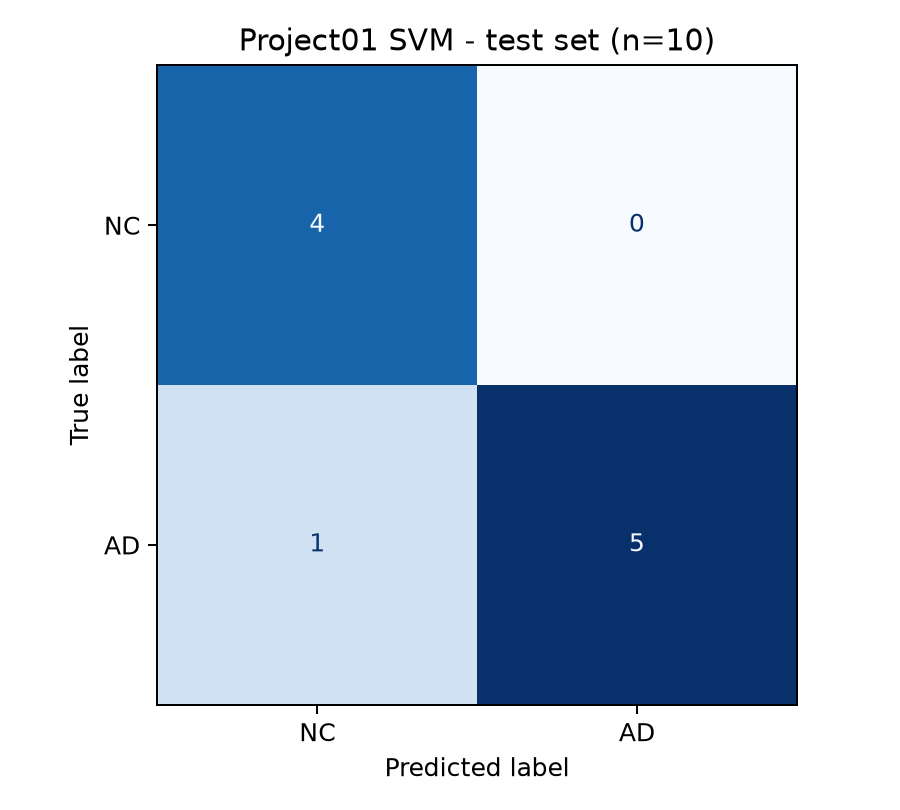

In [5]:
if EVALUATE_TEST:
    metrics = evaluate_predictions(predictions, LABELS_CSV, OUTPUT_DIR)
    print(f"Test accuracy: {metrics['accuracy']:.1%} ({metrics['correct_predictions']}/10)")
    print(f"AD sensitivity: {metrics['sensitivity_AD']:.1%}")
    print(f"NC specificity: {metrics['specificity_NC']:.1%}")
    display(pd.read_csv(OUTPUT_DIR / "test_evaluation.csv"))
    display(Image(filename=str(OUTPUT_DIR / "test_confusion_matrix.png")))
else:
    print("Predictions saved; test-label evaluation skipped.")


## Outputs and method record

- `results/test_predictions.csv`: the required 10-subject AD/NC prediction table.
- `results/training_record.json`: fixed settings, training class counts, CV scores, scaler parameters, software versions, and input checksums.
- `results/svm_model.joblib`: fitted scaler/SVM, feature order, and label encoding.
- Evaluation also generates `test_metrics.json`, `test_evaluation.csv`, and `test_confusion_matrix.png`.

Data_44 volumes come from the agreed BET result. Known brain-boundary issues remain in the preprocessing records; the subject is retained and its measured volumes are used as supplied. Any future kernel or C/gamma selection should use training-only validation and preserve an independent test set.

Course basis: Section IV, Support Vector Machine, of the supplied Lab 2 notebook, and the 40/10 split, 90 features, and standardization suggestion in Project 1 description 2026.

API references: [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html), [Pipeline and data leakage](https://scikit-learn.org/stable/common_pitfalls.html), [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html).
